# Week 10 consolidated Bayesian optimisation notebook

This notebook presents Functions 1–8 in one systematic analytical record. Every function follows the same eleven-stage sequence below. UCB results are unevaluated proposals and are never appended as returned observations.

**Evidence used:** starter observations plus immutable-ledger returns through Week 09.

## Table of contents

1. Create week's_dataset by appending the previous output results
2. Extract the function
3. Check shapes and missing values
4. Calculate summary statistics
5. Plot the output trend
6. Plot the best-so-far trend
7. Identify the best query point
8. Plot the correlation heatmap
9. Plot each input against the output
10. Fit a Gaussian Process surrogate
11. Apply UCB to generate the next query point

# Function 1

Function 1 uses the verified evidence available before Week 10.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 10, 1, 2, 9
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [2]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,output
observation,,,,
9,starter,0.883890,0.582254,6.229856e-48
10,week_01,0.374540,0.950714,-1.560647e-117
11,week_02,0.536429,0.835362,1.674933e-36
12,week_03,0.614168,0.334143,-1.075594e-32
13,week_04,0.872626,0.321598,-2.466641e-107
14,week_05,0.897714,0.081699,7.651210e-239
15,week_06,0.222521,0.999673,6.131855e-211
16,week_07,0.350420,0.999543,-6.738616e-151
17,week_08,0.397837,0.919531,-1.772400e-96


## 2. Extract the function

In [3]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 1: 2 input dimensions, 19 verified observations


## 3. Check shapes and missing values

In [4]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(19, 2)"
1,output shape,"(19,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [5]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,19.0,0.535570,0.241221,0.082507,3.624800e-01,5.364290e-01,7.072209e-01,8.977140e-01
x2,19.0,0.619645,0.328911,0.078723,3.278705e-01,7.329999e-01,8.997146e-01,9.996730e-01
output,19.0,-0.000190,0.000827,-0.003606,-2.430912e-96,7.651210e-239,3.114928e-48,7.710875e-16


## 5. Plot the output trend

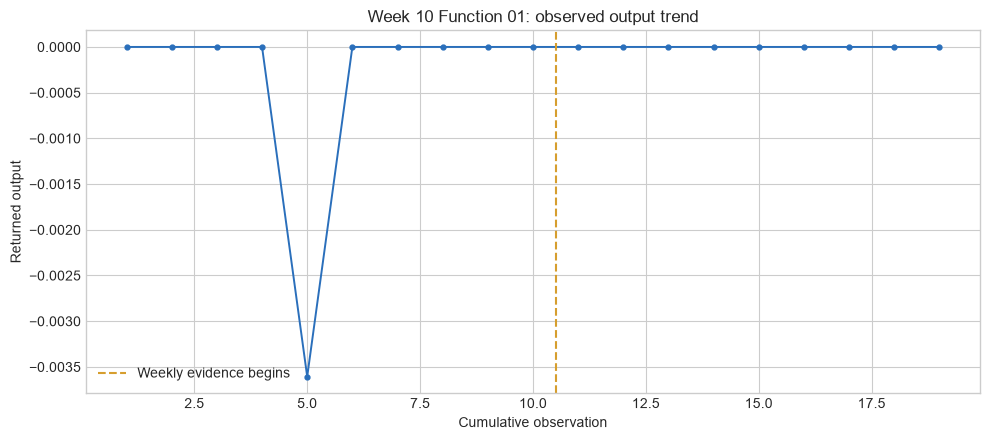

In [6]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

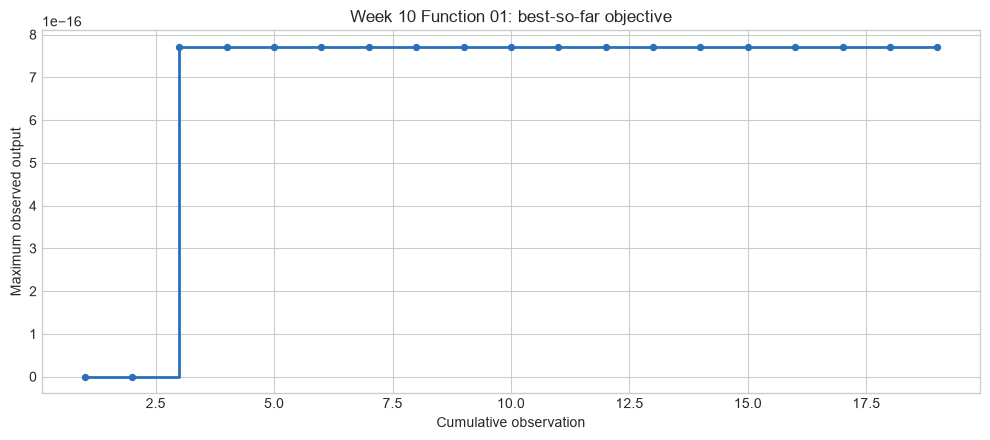

In [7]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [8]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,output
0,3,starter,0.731024,0.733,7.710875e-16


## 8. Plot the correlation heatmap

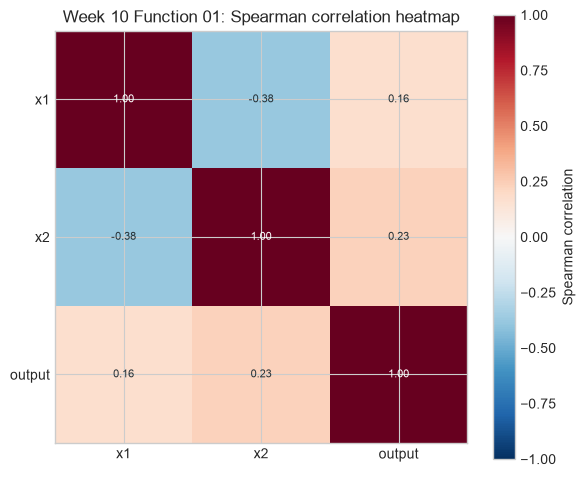

In [9]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

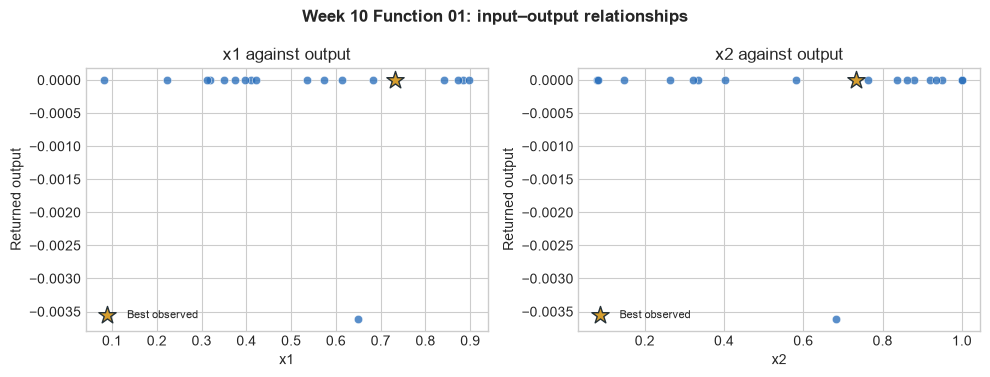

In [10]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [11]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.16**2 * Matern(length_scale=[10, 0.0448], nu=2.5) + WhiteKernel(noise_level=1.38e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [12]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_1:0.785006-0.508891


,week,function,kappa,x1,x2,predicted_mean,predicted_std,ucb_score,status
0,10,1,2.0,0.785006,0.508891,-0.00006,0.000905,0.00175,proposed_not_evaluated


# Function 2

Function 2 uses the verified evidence available before Week 10.

In [13]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 10, 2, 2, 9
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [14]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,output
observation,,,,
9,starter,0.702637,0.926564,0.611205
10,week_01,0.374540,0.950714,-0.031830
11,week_02,0.978752,0.932731,0.022667
12,week_03,0.000006,0.334143,0.048684
13,week_04,0.197553,0.808683,0.038775
14,week_05,0.555332,0.360931,0.220781
15,week_06,0.473151,0.950706,0.160532
16,week_07,0.009675,0.999881,0.048714
17,week_08,0.314242,0.973527,0.072764


## 2. Extract the function

In [15]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 2: 2 input dimensions, 19 verified observations


## 3. Check shapes and missing values

In [16]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(19, 2)"
1,output shape,"(19,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [17]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,19.0,0.488618,0.300851,0.000006,0.326445,0.454647,0.684218,0.995366
x2,19.0,0.594387,0.343414,0.028698,0.312299,0.711120,0.929648,0.999881
output,19.0,0.154591,0.193785,-0.065624,0.030927,0.049406,0.232700,0.611205


## 5. Plot the output trend

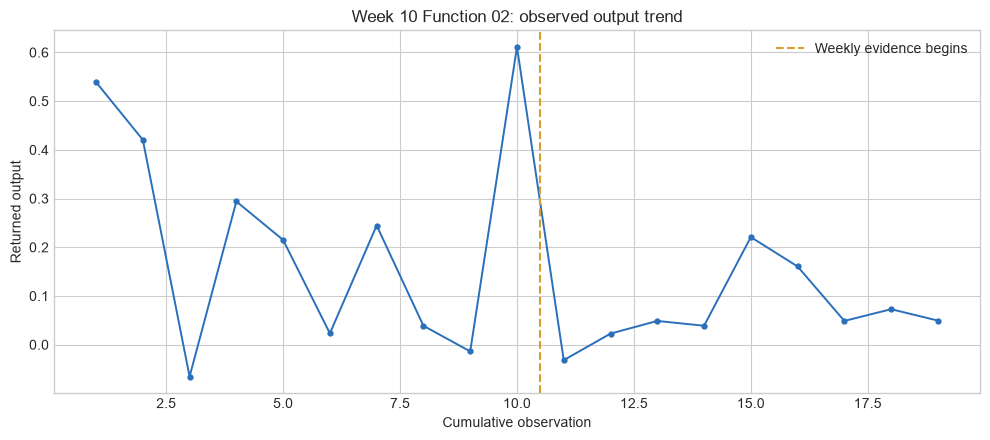

In [18]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

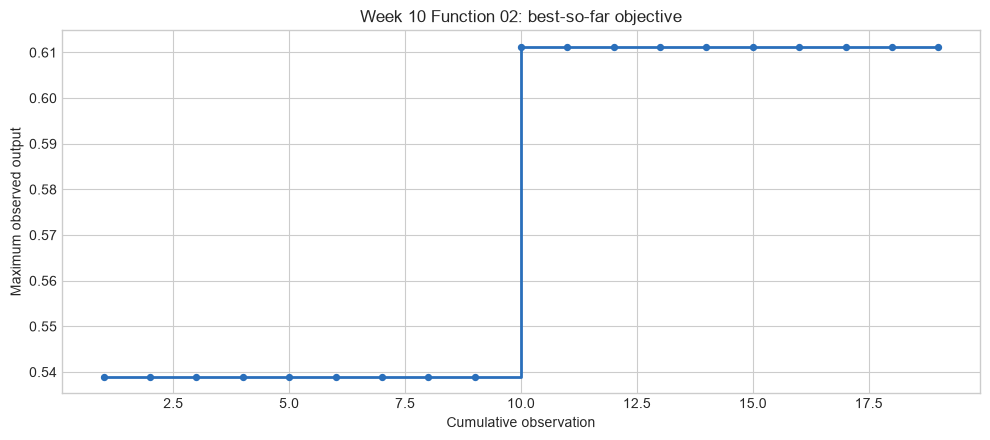

In [19]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [20]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,output
0,10,starter,0.702637,0.926564,0.611205


## 8. Plot the correlation heatmap

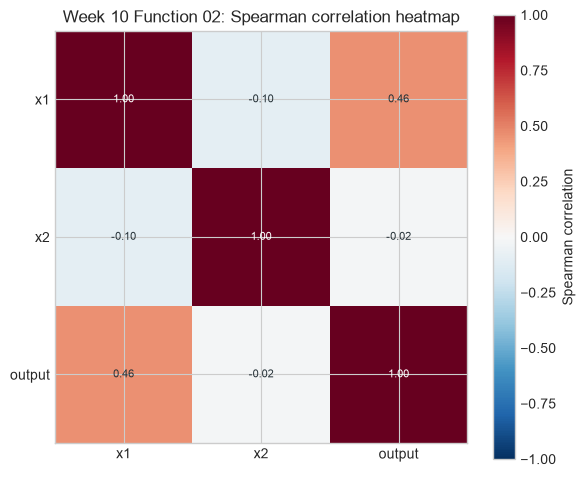

In [21]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

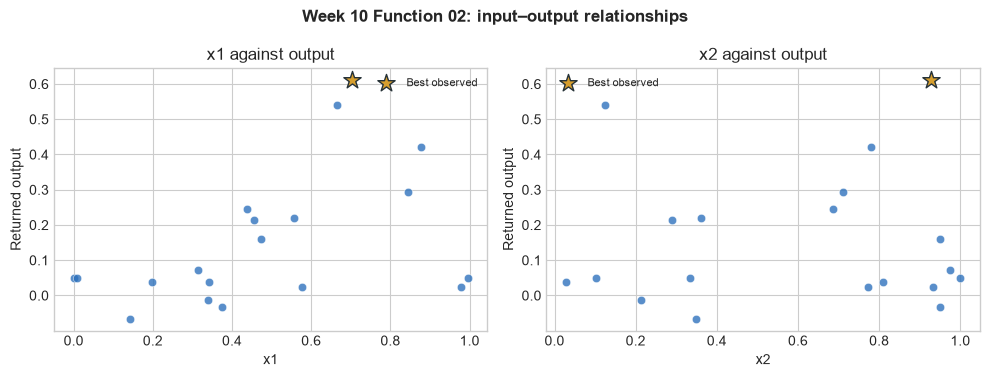

In [22]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [23]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 0.988**2 * Matern(length_scale=[0.0473, 10], nu=2.5) + WhiteKernel(noise_level=0.0271)
Training R²: 0.9958


## 11. Apply UCB to generate the next query point

In [24]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_2:0.688130-0.052013


,week,function,kappa,x1,x2,predicted_mean,predicted_std,ucb_score,status
0,10,2,2.0,0.68813,0.052013,0.611143,0.056242,0.723627,proposed_not_evaluated


# Function 3

Function 3 uses the verified evidence available before Week 10.

In [25]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 10, 3, 3, 9
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [26]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,output
observation,,,,,
14,starter,0.965995,0.861120,0.566829,-0.056758
15,week_01,0.444444,0.666666,0.333333,-0.040908
16,week_02,0.657452,0.998464,0.817253,-0.089875
17,week_03,0.670026,0.057881,0.658241,-0.183239
18,week_04,0.650132,0.218327,0.110542,-0.082513
19,week_05,0.522711,0.090769,0.451242,-0.057397
20,week_06,0.418776,0.420613,0.695421,-0.117005
21,week_07,0.427731,0.669810,0.343678,-0.047183
22,week_08,0.457347,0.664022,0.295993,-0.077413


## 2. Extract the function

In [27]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 3: 3 input dimensions, 24 verified observations


## 3. Check shapes and missing values

In [28]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(24, 3)"
1,output shape,"(24,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [29]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,24.0,0.451380,0.230550,0.046809,0.236723,0.453191,0.646660,0.965995
x2,24.0,0.508999,0.261269,0.057881,0.294418,0.525792,0.670354,0.998464
x3,24.0,0.418246,0.261048,0.066089,0.248127,0.336755,0.589682,0.990882
output,24.0,-0.099372,0.073337,-0.398926,-0.112559,-0.088919,-0.054571,-0.034835


## 5. Plot the output trend

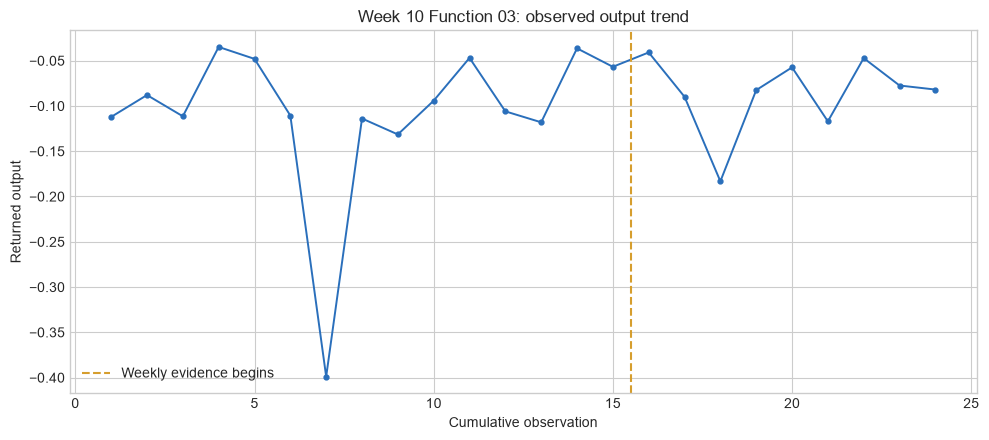

In [30]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

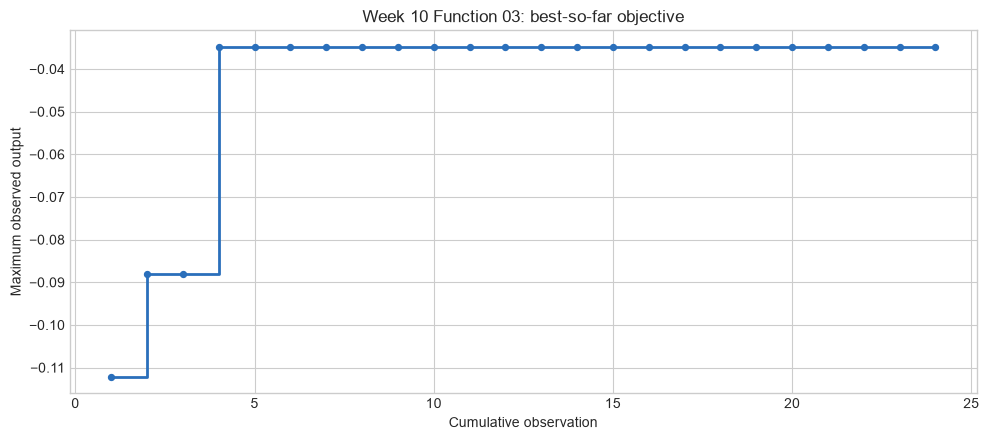

In [31]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [32]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,output
0,4,starter,0.492581,0.611593,0.340176,-0.034835


## 8. Plot the correlation heatmap

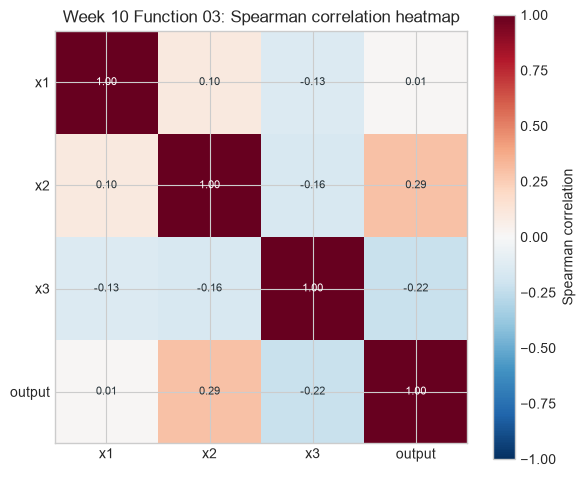

In [33]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

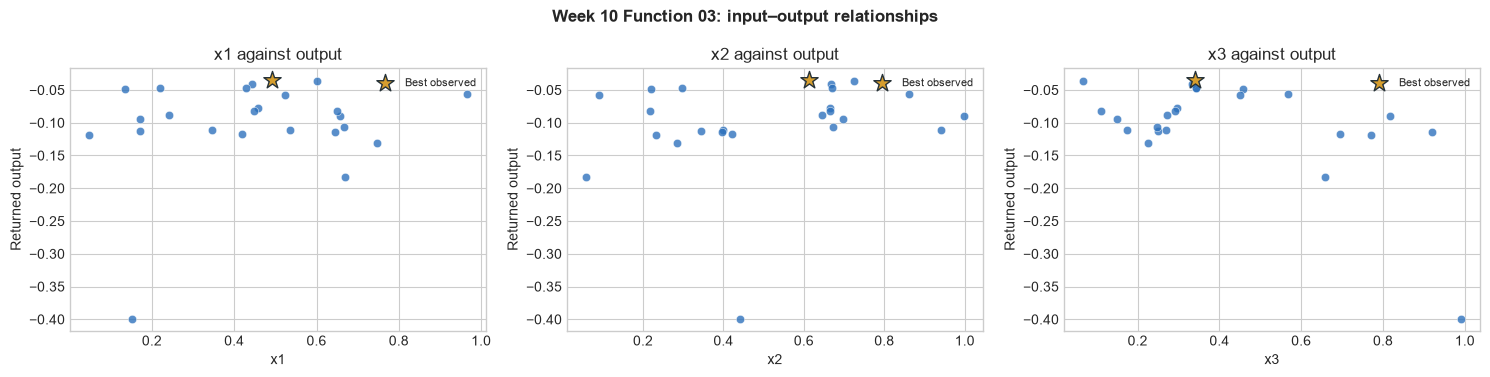

In [34]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [35]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.33**2 * Matern(length_scale=[10, 0.824, 0.0796], nu=2.5) + WhiteKernel(noise_level=1.09e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [36]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_3:0.899228-0.106351-0.001331


,week,function,kappa,x1,x2,x3,predicted_mean,predicted_std,ucb_score,status
0,10,3,2.0,0.899228,0.106351,0.001331,-0.069562,0.083156,0.096751,proposed_not_evaluated


# Function 4

Function 4 uses the verified evidence available before Week 10.

In [37]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 10, 4, 4, 9
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [38]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,output
observation,,,,,,
29,starter,0.854811,0.493965,0.735310,0.808092,-23.139428
30,week_01,0.555555,0.444444,0.222222,0.111111,-8.727516
31,week_02,0.006280,0.281840,0.932013,0.960202,-31.735358
32,week_03,0.394519,0.361122,0.256803,0.461856,-1.981075
33,week_04,0.715715,0.504442,0.275065,0.552962,-9.312812
34,week_05,0.713766,0.198601,0.014095,0.068347,-17.926307
35,week_06,0.753422,0.441826,0.942545,0.489846,-20.879363
36,week_07,0.096005,0.028299,0.033322,0.077327,-20.195854
37,week_08,0.046009,0.778273,0.979511,0.088488,-28.736323


## 2. Extract the function

In [39]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 4: 4 input dimensions, 39 verified observations


## 3. Check shapes and missing values

In [40]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(39, 4)"
1,output shape,"(39,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [41]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,39.0,0.524537,0.302354,0.006280,0.249327,0.577766,0.750062,0.985622
x2,39.0,0.445017,0.298078,0.002958,0.155668,0.482103,0.696280,0.919592
x3,39.0,0.463393,0.291279,0.014095,0.219731,0.438806,0.722338,0.979511
x4,39.0,0.456604,0.299271,0.068347,0.164234,0.489846,0.746945,0.999483
output,39.0,-17.437821,7.689938,-32.625660,-22.623858,-16.507159,-12.711725,-1.981075


## 5. Plot the output trend

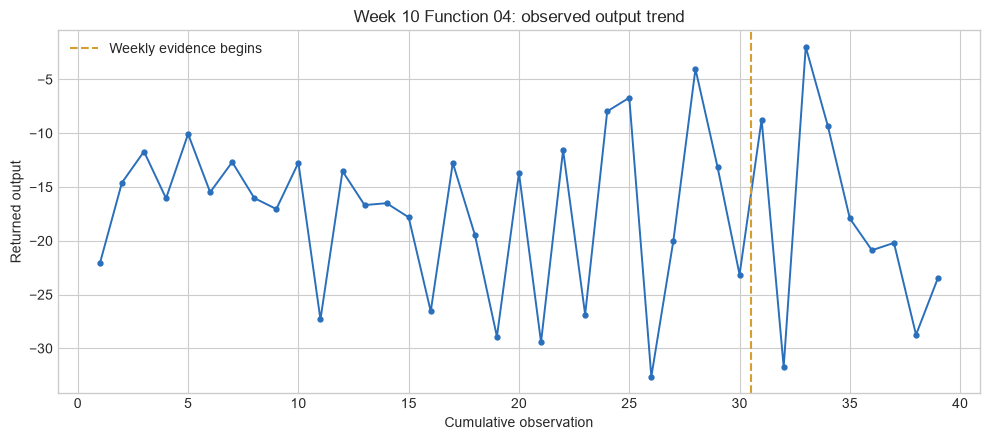

In [42]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

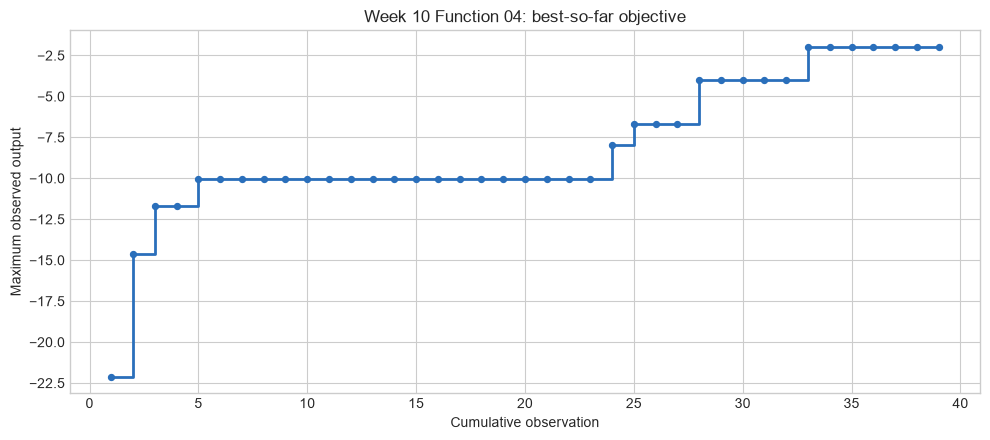

In [43]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [44]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,output
0,33,week_03,0.394519,0.361122,0.256803,0.461856,-1.981075


## 8. Plot the correlation heatmap

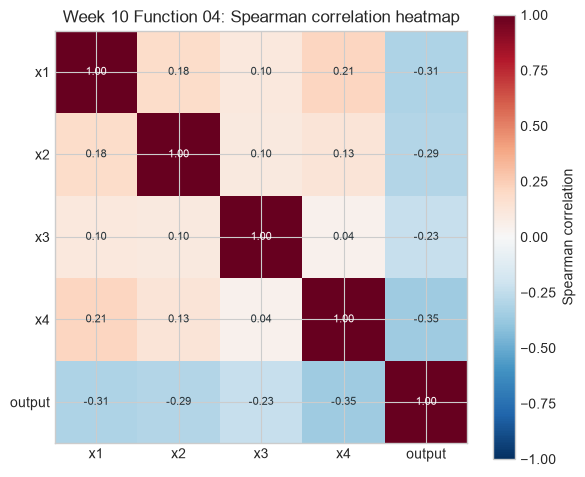

In [45]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

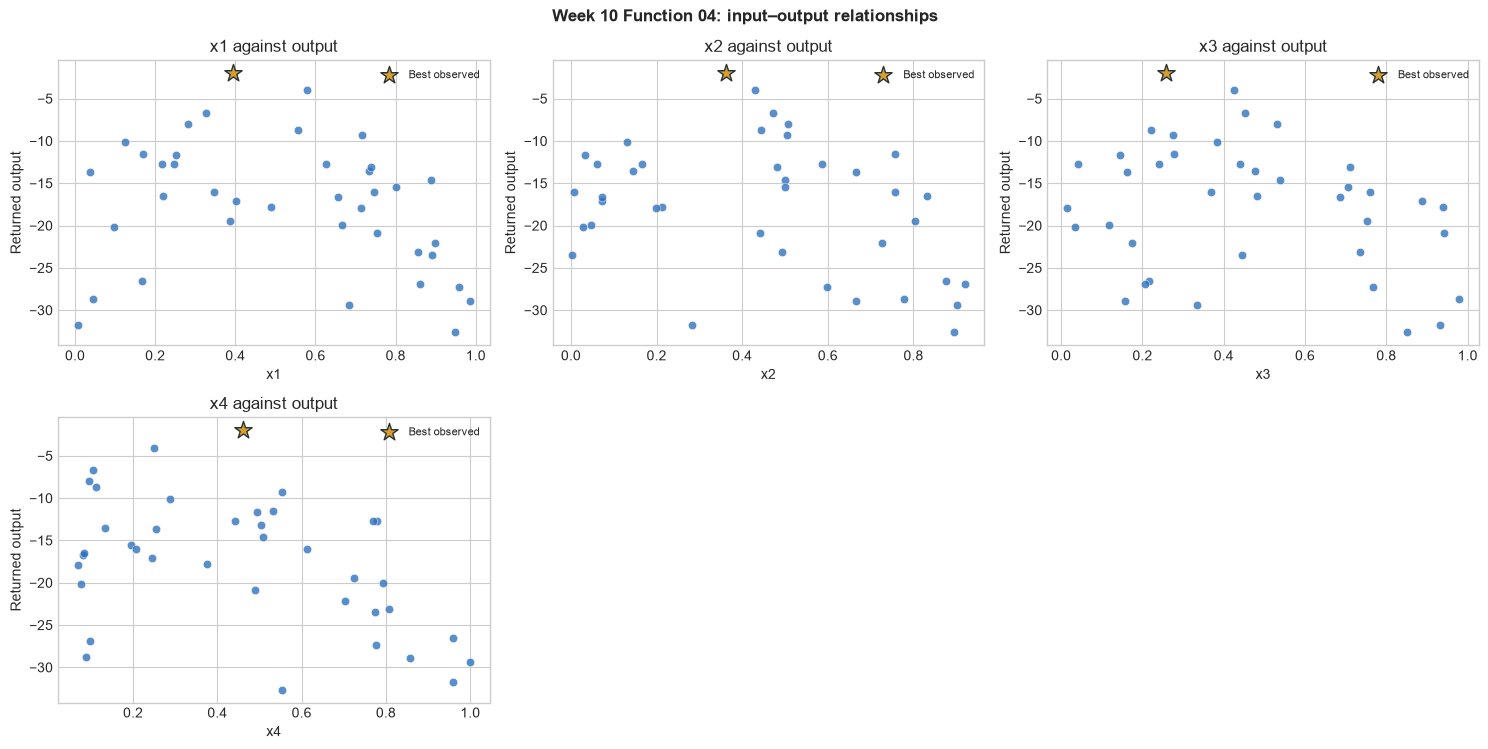

In [46]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [47]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 5.57**2 * Matern(length_scale=[2.24, 2.22, 2.34, 2.34], nu=2.5) + WhiteKernel(noise_level=0.00185)
Training R²: 0.9998


## 11. Apply UCB to generate the next query point

In [48]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_4:0.410116-0.406661-0.361956-0.467691


,week,function,kappa,x1,x2,x3,x4,predicted_mean,predicted_std,ucb_score,status
0,10,4,2.0,0.410116,0.406661,0.361956,0.467691,-1.461398,0.505087,-0.451224,proposed_not_evaluated


# Function 5

Function 5 uses the verified evidence available before Week 10.

In [49]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 10, 5, 4, 9
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [50]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,output
observation,,,,,,
19,starter,0.126885,0.153430,0.770162,0.190518,9.972332
20,week_01,0.224189,0.846480,0.879484,0.878515,1088.853511
21,week_02,0.255841,0.841692,0.888984,0.860260,1035.634146
22,week_03,0.255842,0.841692,0.888985,0.860266,1035.664748
23,week_04,0.000000,0.000000,0.000000,0.000000,163.122500
24,week_05,0.754614,0.504566,0.432986,0.307039,0.940116
25,week_06,0.654981,0.602894,0.898891,0.589622,281.911573
26,week_07,0.000000,0.000000,0.000000,0.000000,163.122500
27,week_08,0.081230,0.992582,0.156202,0.988421,1465.512192


## 2. Extract the function

In [51]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 5: 4 input dimensions, 29 verified observations


## 3. Check shapes and missing values

In [52]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(29, 4)"
1,output shape,"(29,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [53]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,29.0,0.405323,0.249586,0.00000,0.224189,0.355482,0.654981,0.836478
x2,29.0,0.526774,0.301146,0.00000,0.316878,0.602894,0.804340,0.992582
x3,29.0,0.487450,0.292497,0.00000,0.264243,0.432986,0.728710,0.898891
x4,29.0,0.530293,0.339032,0.00000,0.190518,0.482088,0.860260,1.000000
output,29.0,299.689722,416.445961,0.11294,28.866752,79.729130,355.806818,1465.512192


## 5. Plot the output trend

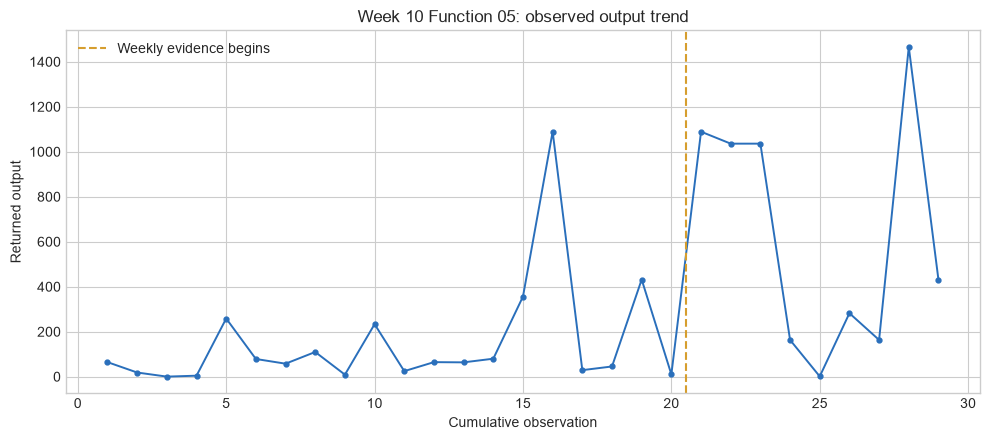

In [54]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

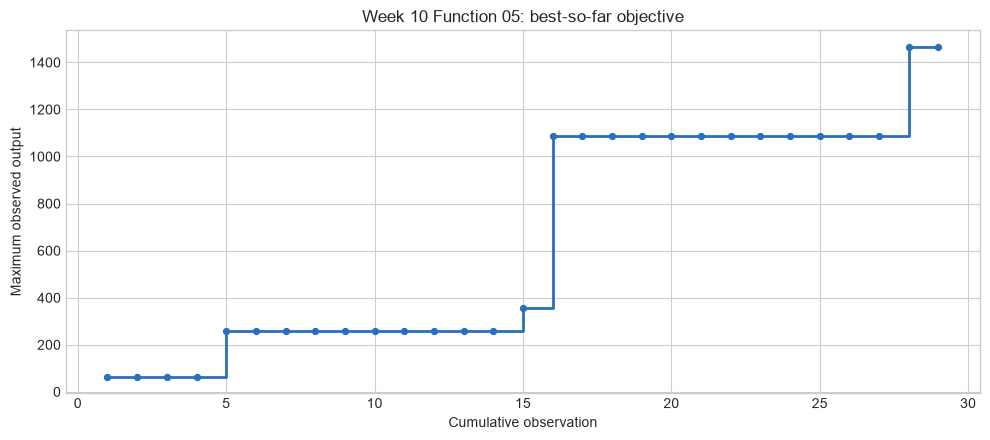

In [55]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [56]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,output
0,28,week_08,0.08123,0.992582,0.156202,0.988421,1465.512192


## 8. Plot the correlation heatmap

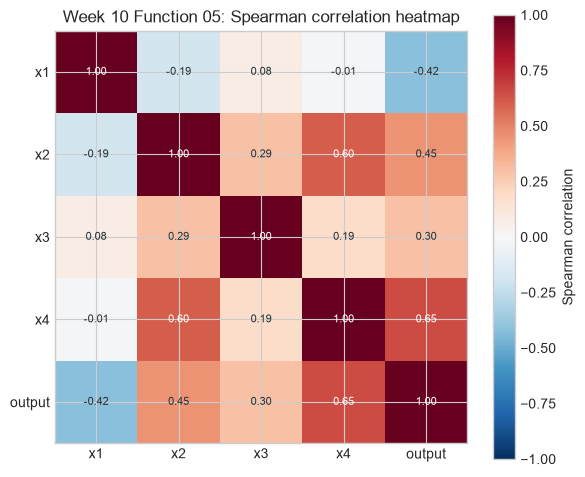

In [57]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

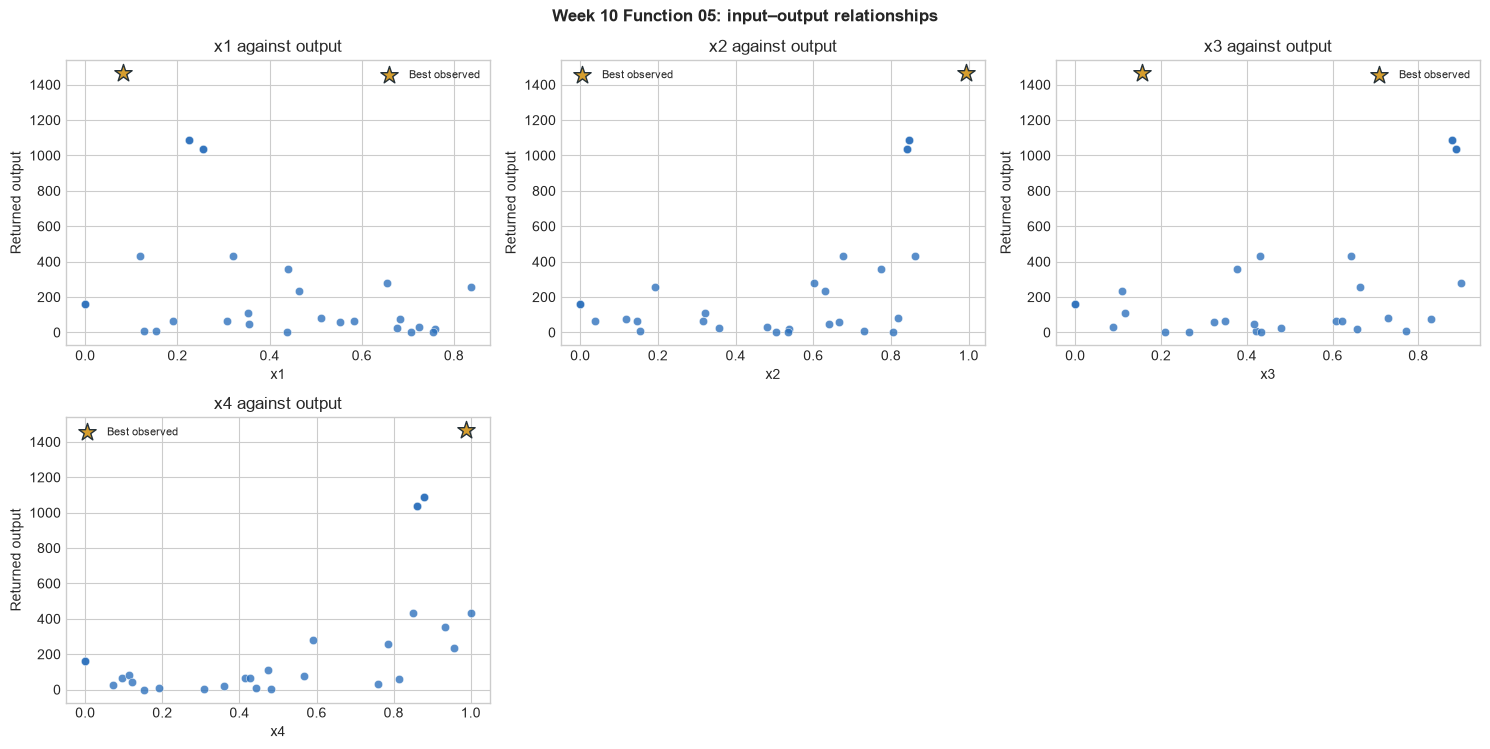

In [58]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [59]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 3.21**2 * Matern(length_scale=[10, 0.974, 1.08, 0.963], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [60]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_5:0.560928-0.973465-0.953326-0.987380


,week,function,kappa,x1,x2,x3,x4,predicted_mean,predicted_std,ucb_score,status
0,10,5,2.0,0.560928,0.973465,0.953326,0.98738,1781.401363,174.646785,2130.694933,proposed_not_evaluated


# Function 6

Function 6 uses the verified evidence available before Week 10.

In [61]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 10, 6, 5, 9
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [62]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,output
observation,,,,,,,
19,starter,0.126679,0.291470,0.064528,0.680515,0.892819,-1.746882
20,week_01,0.728186,0.154693,0.732552,0.693997,0.564013,-1.152035
21,week_02,0.433654,0.486678,0.282753,0.972905,0.323321,-0.878241
22,week_03,0.495070,0.097152,0.672921,0.000007,0.351268,-1.339542
23,week_04,0.973181,0.022807,0.714484,0.145453,0.974790,-2.437508
24,week_05,0.824244,0.022732,0.960907,0.041715,0.897560,-2.529369
25,week_06,0.781770,0.192076,0.805757,0.695733,0.565940,-1.312540
26,week_07,0.683830,0.035248,0.777884,0.740721,0.629310,-1.287089
27,week_08,0.994993,0.316819,0.508801,0.557706,0.579403,-1.479452


## 2. Extract the function

In [63]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 6: 5 input dimensions, 29 verified observations


## 3. Check shapes and missing values

In [64]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(29, 5)"
1,output shape,"(29,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [65]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,29.0,0.606276,0.283549,0.021735,0.433654,0.711755,0.782880,0.994993
x2,29.0,0.439837,0.309863,0.022732,0.175670,0.331802,0.748106,0.931871
x3,29.0,0.535820,0.298226,0.016523,0.341819,0.642114,0.738396,0.978806
x4,29.0,0.525051,0.297634,0.000007,0.246605,0.648324,0.705000,0.972905
x5,29.0,0.480111,0.283804,0.004911,0.273549,0.562717,0.629310,0.974790
output,29.0,-1.499838,0.488914,-2.571170,-1.702558,-1.339542,-1.209955,-0.714265


## 5. Plot the output trend

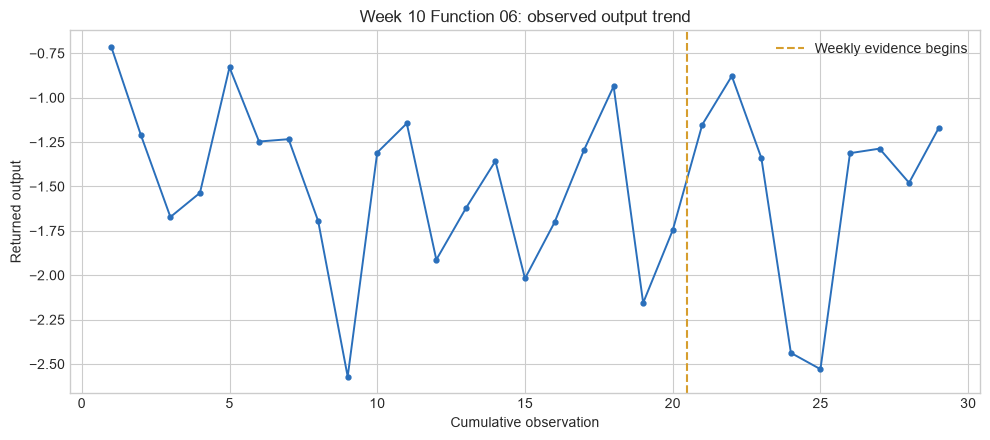

In [66]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

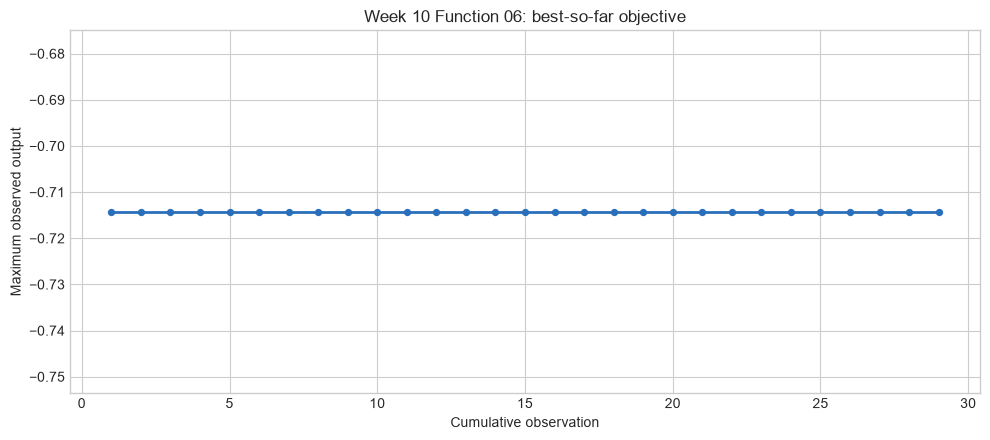

In [67]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [68]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,output
0,1,starter,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265


## 8. Plot the correlation heatmap

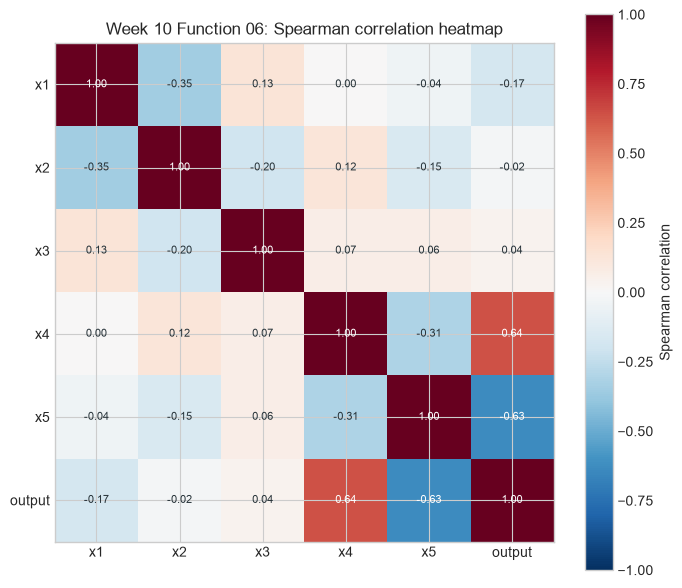

In [69]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

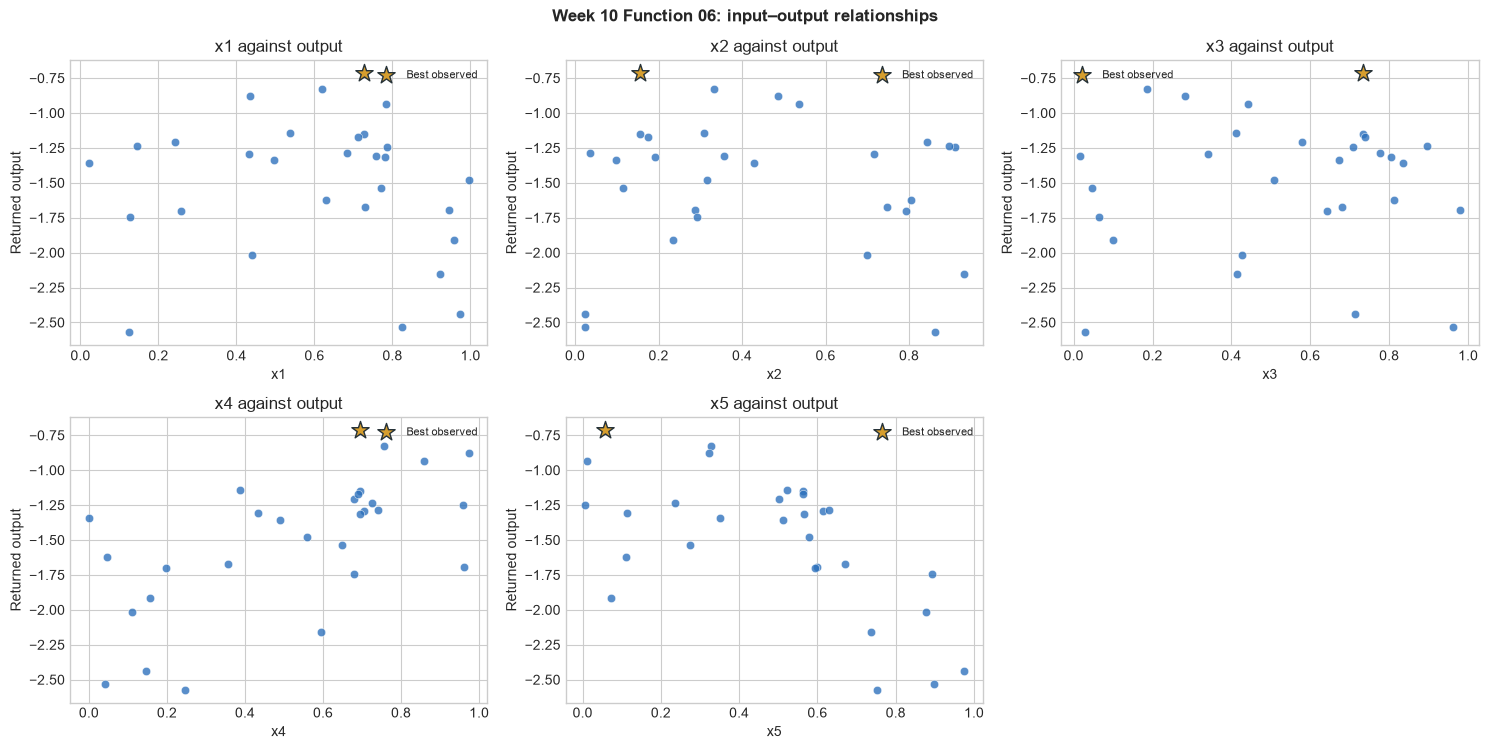

In [70]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [71]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.86**2 * Matern(length_scale=[1.01, 0.792, 1.01, 1.62, 1.61], nu=2.5) + WhiteKernel(noise_level=0.00202)
Training R²: 0.9999


## 11. Apply UCB to generate the next query point

In [72]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_6:0.212787-0.127642-0.793122-0.916030-0.022863


,week,function,kappa,x1,x2,x3,x4,x5,predicted_mean,predicted_std,ucb_score,status
0,10,6,2.0,0.212787,0.127642,0.793122,0.91603,0.022863,-0.717268,0.319553,-0.078162,proposed_not_evaluated


# Function 7

Function 7 uses the verified evidence available before Week 10.

In [73]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 10, 7, 6, 9
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [74]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,x6,output
observation,,,,,,,,
29,starter,0.476823,0.340942,0.014335,0.880140,0.998655,0.079664,0.095411
30,week_01,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,1.051015
31,week_02,0.243848,0.900100,0.696978,0.193630,0.374149,0.826324,0.308765
32,week_03,0.143585,0.302559,0.571101,0.194533,0.395561,0.815792,2.149905
33,week_04,0.045103,0.016167,0.773003,0.156031,0.147073,0.616114,1.208733
34,week_05,0.025337,0.910075,0.727790,0.075231,0.386516,0.492629,0.190783
35,week_06,0.042873,0.466831,0.379623,0.207090,0.367754,0.515646,1.611967
36,week_07,0.121173,0.544849,0.282921,0.037758,0.374065,0.591179,0.899499
37,week_08,0.016174,0.558963,0.348588,0.050763,0.417748,0.644030,0.846180


## 2. Extract the function

In [75]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 7: 6 input dimensions, 39 verified observations


## 3. Check shapes and missing values

In [76]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(39, 6)"
1,output shape,"(39,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [77]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,39.0,0.410957,0.325397,0.016174,0.104850,0.319810,0.724450,0.942451
x2,39.0,0.426493,0.260301,0.011813,0.230167,0.464896,0.553566,0.924694
x3,39.0,0.414727,0.292051,0.003635,0.189201,0.360096,0.688496,0.924571
x4,39.0,0.423052,0.320530,0.037758,0.160602,0.285009,0.744094,0.961017
x5,39.0,0.445054,0.280925,0.014944,0.225290,0.413631,0.687320,0.998655
x6,39.0,0.520486,0.250088,0.051100,0.354190,0.614974,0.702187,0.951014
output,39.0,0.406793,0.517953,0.002701,0.027454,0.190783,0.607979,2.149905


## 5. Plot the output trend

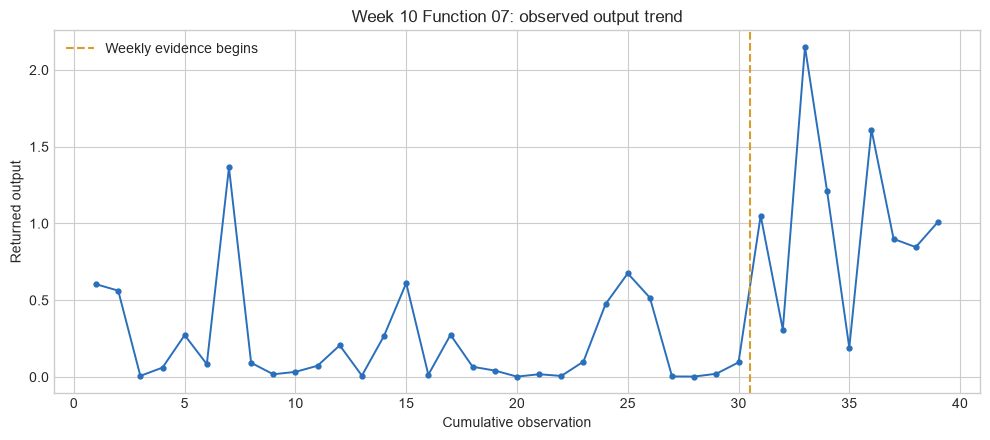

In [78]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

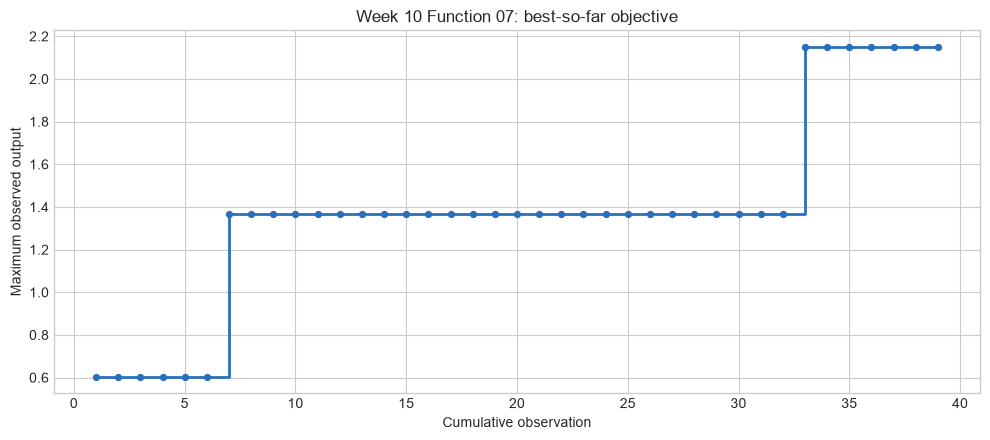

In [79]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [80]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,x6,output
0,33,week_03,0.143585,0.302559,0.571101,0.194533,0.395561,0.815792,2.149905


## 8. Plot the correlation heatmap

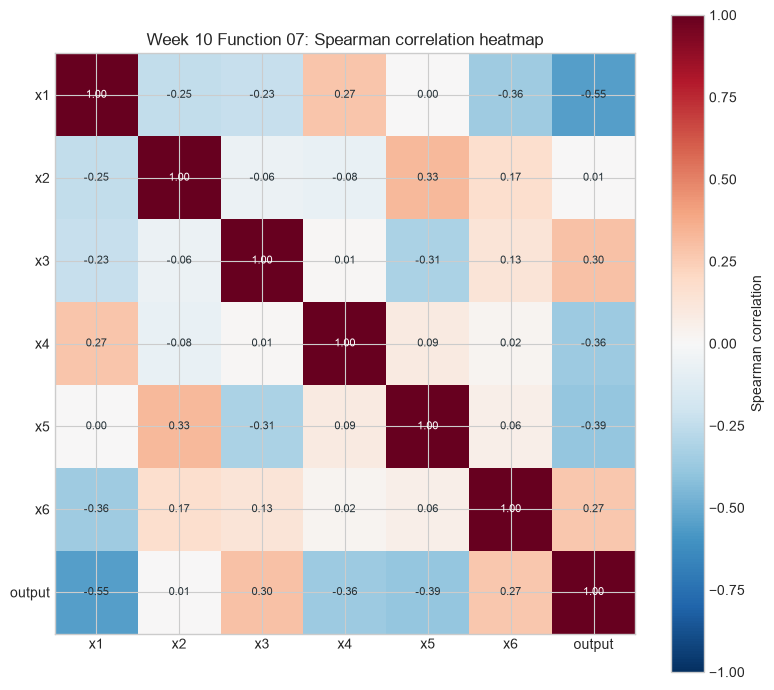

In [81]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

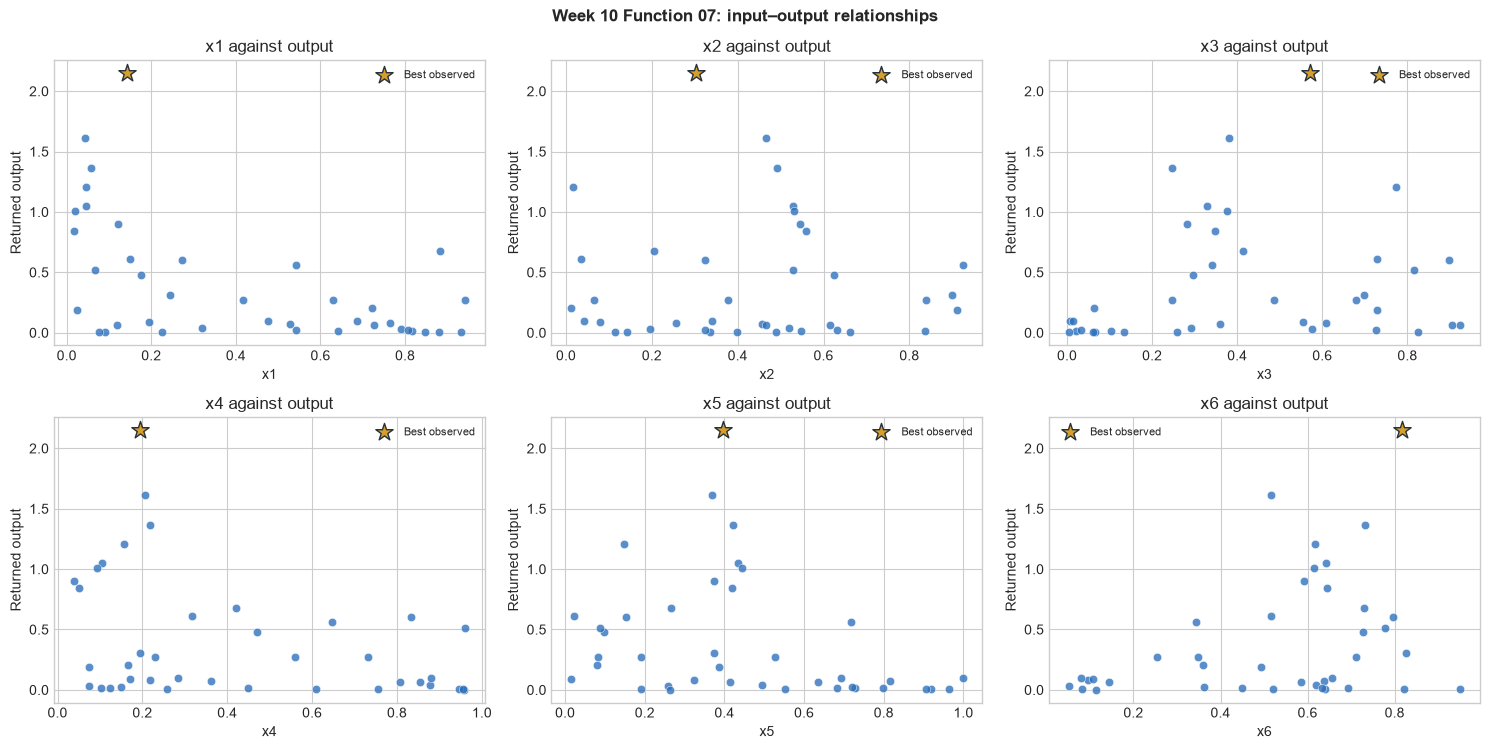

In [82]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [83]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 0.992**2 * Matern(length_scale=[0.835, 0.351, 10, 0.558, 0.368, 0.807], nu=2.5) + WhiteKernel(noise_level=1.06e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [84]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_7:0.062149-0.162075-0.986726-0.116948-0.321647-0.890970


,week,function,kappa,x1,x2,x3,x4,x5,x6,predicted_mean,predicted_std,ucb_score,status
0,10,7,2.0,0.062149,0.162075,0.986726,0.116948,0.321647,0.89097,2.070242,0.186029,2.442301,proposed_not_evaluated


# Function 8

Function 8 uses the verified evidence available before Week 10.

In [85]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 10, 8, 8, 9
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [86]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,x6,x7,x8,output
observation,,,,,,,,,,
39,starter,0.481245,0.102461,0.219486,0.677322,0.247509,0.244341,0.163825,0.715962,9.183005
40,week_01,0.273673,0.260400,0.073937,0.078562,0.862321,0.230729,0.108688,0.352588,9.815709
41,week_02,0.163160,0.184786,0.152644,0.083802,0.999322,0.544113,0.184124,0.123846,9.939904
42,week_03,0.088894,0.525132,0.030986,0.992538,0.870819,0.217060,0.011239,0.447691,8.963604
43,week_04,0.356502,0.157574,0.172997,0.610561,0.106477,0.260297,0.411421,0.904740,9.254064
44,week_05,0.110992,0.022977,0.255313,0.963757,0.895383,0.716713,0.030436,0.083412,9.138609
45,week_06,0.115956,0.821931,0.587418,0.022809,0.440260,0.965550,0.368459,0.301774,8.557034
46,week_07,0.006802,0.833571,0.147083,0.461921,0.263530,0.887722,0.724982,0.315234,8.563639
47,week_08,0.712683,0.197193,0.129585,0.337018,0.771044,0.106613,0.229839,0.008464,9.020091


## 2. Extract the function

In [87]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 8: 8 input dimensions, 49 verified observations


## 3. Check shapes and missing values

In [88]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(49, 8)"
1,output shape,"(49,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [89]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,49.0,0.480291,0.315128,0.006802,0.176150,0.472071,0.778345,0.985945
x2,49.0,0.451466,0.307438,0.003419,0.184786,0.482734,0.699506,0.973980
x3,49.0,0.453266,0.295868,0.021301,0.232325,0.382124,0.721184,0.998885
x4,49.0,0.423856,0.285129,0.000000,0.147427,0.452656,0.662216,0.992538
x5,49.0,0.507411,0.297305,0.009649,0.247509,0.480619,0.740520,0.999322
x6,49.0,0.460880,0.282576,0.022113,0.244341,0.409325,0.707909,0.990244
x7,49.0,0.516153,0.284747,0.011239,0.254495,0.553779,0.755827,0.992914
x8,49.0,0.466950,0.289944,0.008464,0.205841,0.447691,0.715962,0.988755
output,49.0,8.072725,1.044696,5.592193,7.327435,8.159983,8.963604,9.939904


## 5. Plot the output trend

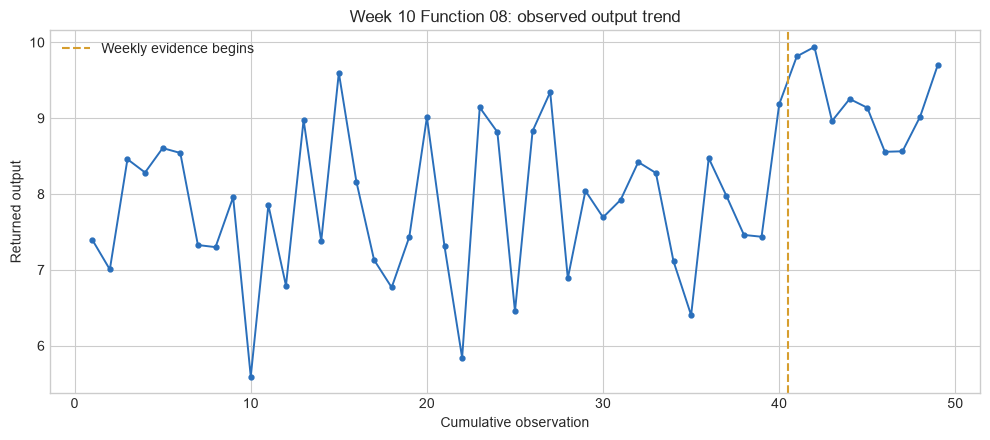

In [90]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

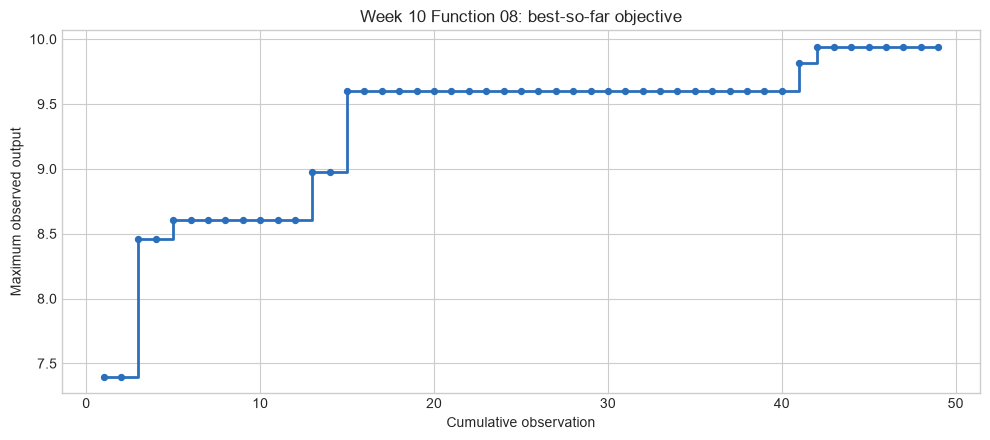

In [91]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [92]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,x6,x7,x8,output
0,42,week_02,0.16316,0.184786,0.152644,0.083802,0.999322,0.544113,0.184124,0.123846,9.939904


## 8. Plot the correlation heatmap

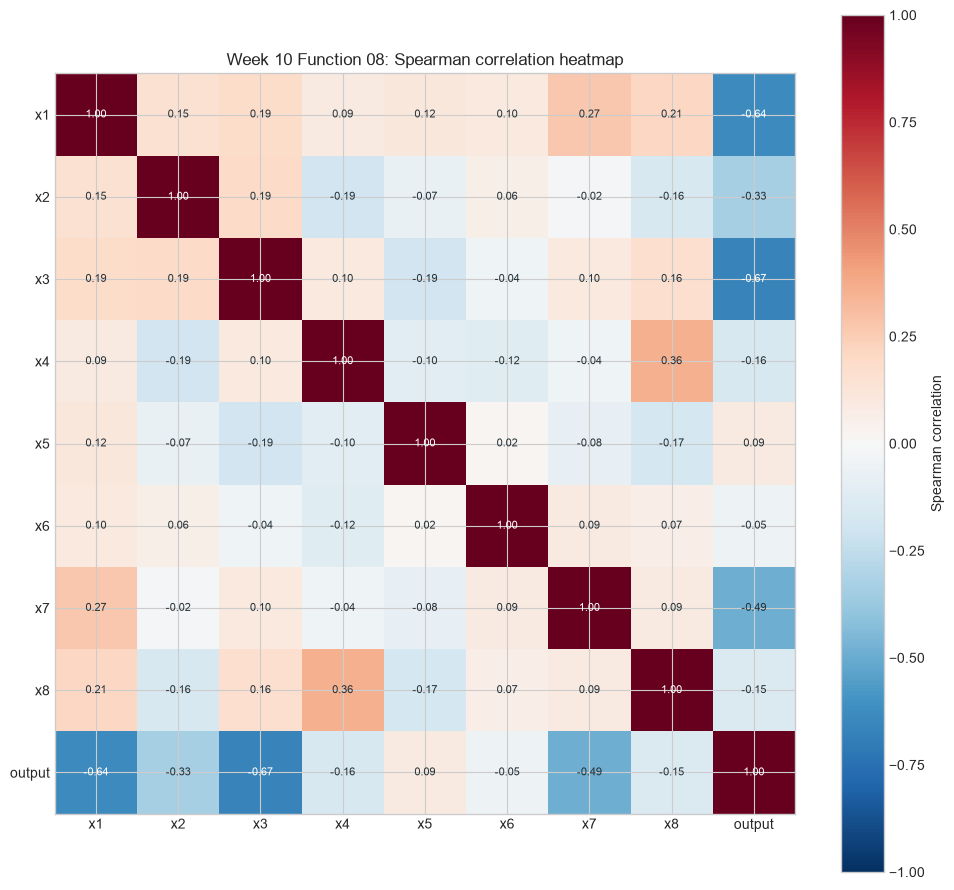

In [93]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

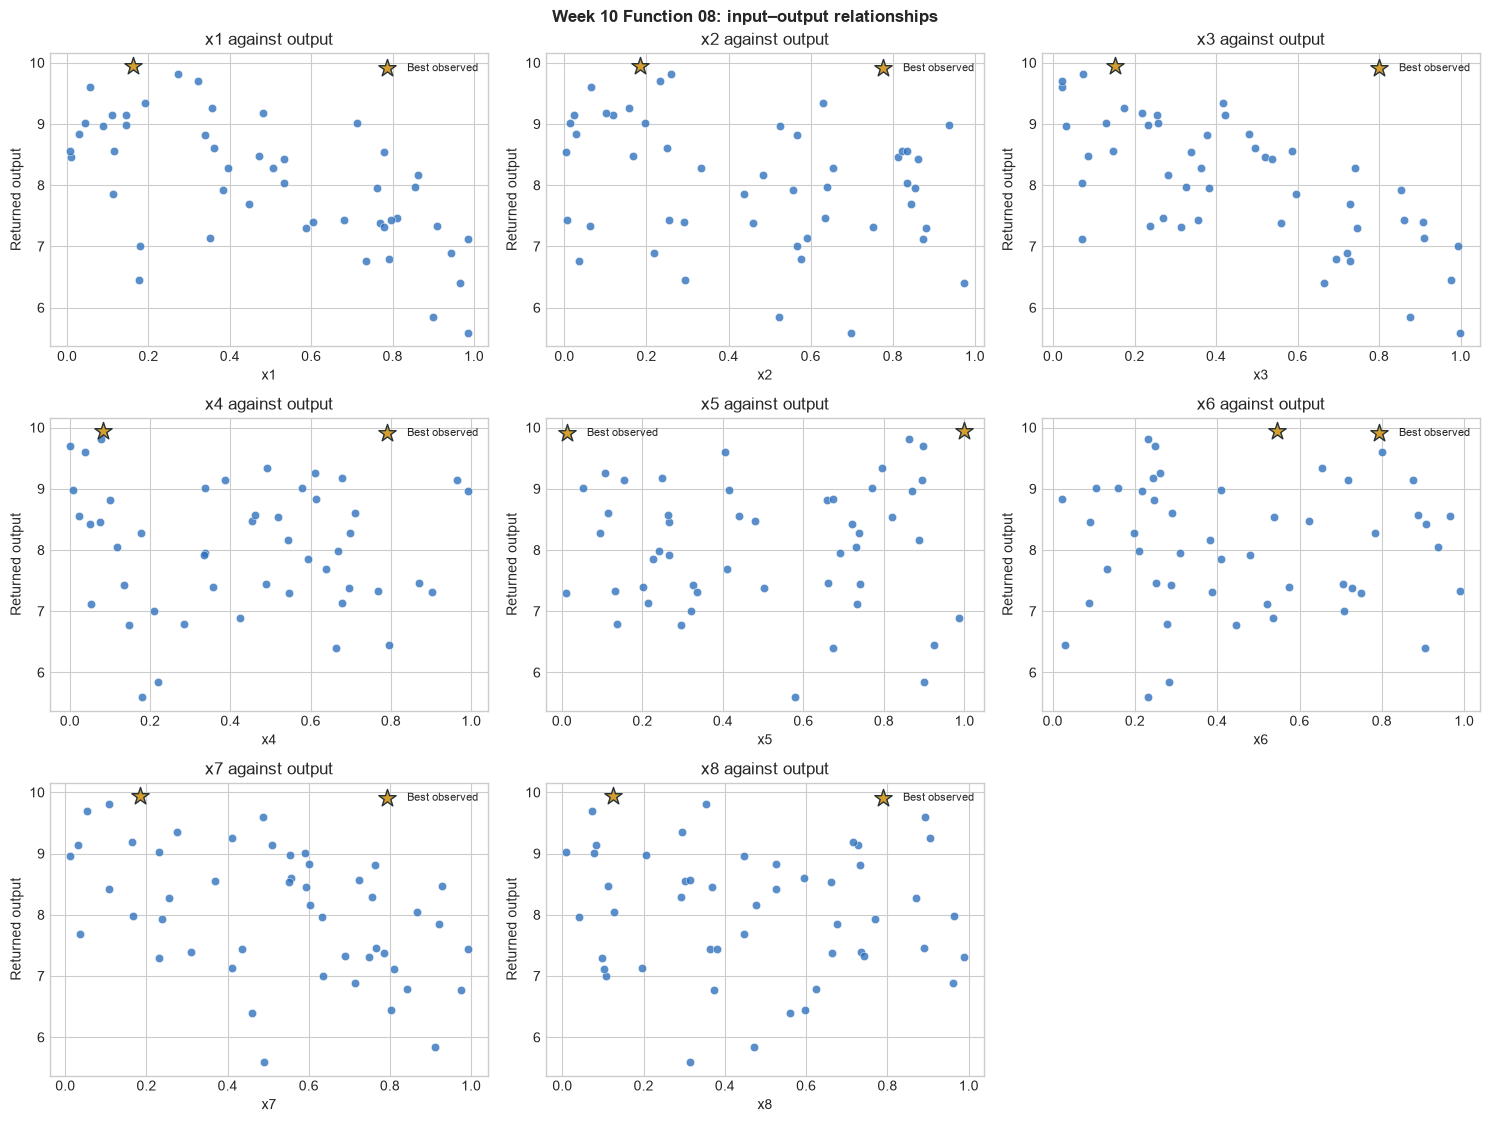

In [94]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [95]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 3.39**2 * Matern(length_scale=[3.25, 4.99, 2.62, 5.09, 10, 4.62, 3.33, 10], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [96]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_8:0.117664-0.341166-0.117354-0.083480-0.980886-0.445300-0.221884-0.870621


,week,function,kappa,x1,x2,x3,x4,x5,x6,x7,x8,predicted_mean,predicted_std,ucb_score,status
0,10,8,2.0,0.117664,0.341166,0.117354,0.08348,0.980886,0.4453,0.221884,0.870621,9.995629,0.064643,10.124916,proposed_not_evaluated
